In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
data=load_iris()
import warnings
warnings.filterwarnings("ignore")

In [3]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")
print(X.head())
print(y.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


In [4]:
X_train, X_test, y_train, y_test =train_test_split(
X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
KNeighborsClassifier()
y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test,y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



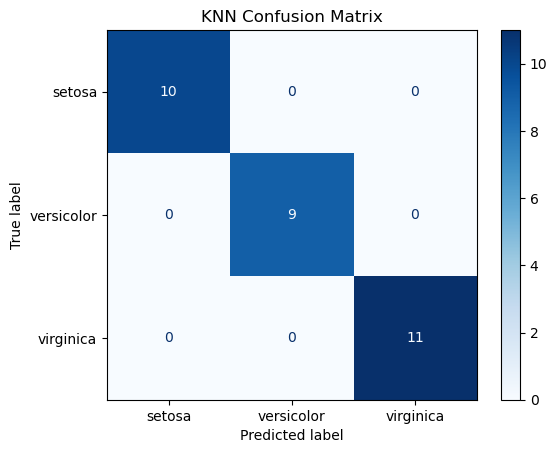

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
display_labels=data.target_names)
disp.plot(cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.show()

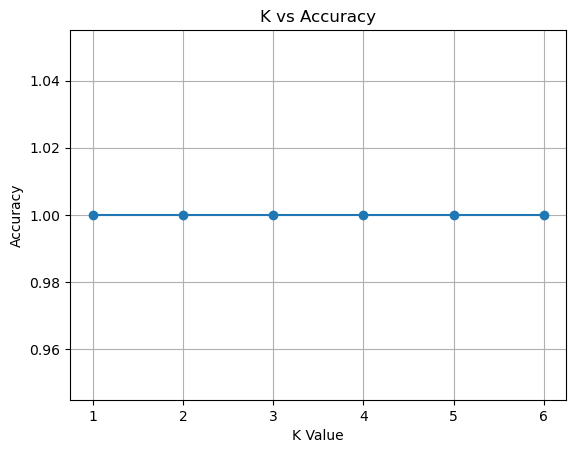

In [11]:
accuracies = []
k_values = range(1, 7)
for k in k_values:
   knn = KNeighborsClassifier(n_neighbors=k)
   knn.fit(X_train, y_train)
   y_pred = knn.predict(X_test)
   accuracies.append(accuracy_score(y_test, y_pred))
plt.plot(k_values, accuracies, marker='o')
plt.title("K vs Accuracy")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [13]:
new_data=np.array([[5.1, 3.5, 1.4, 0.2]])
#scale it using the same scaler
new_data_scaled =scaler.transform(new_data)
prediction =knn.predict(new_data_scaled)
print("predicted class:",data.target_names[prediction][0])

predicted class: setosa
